In [1]:
from pathlib import Path
from collections import Counter
from typing import Callable
import random
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")

cuda available
gpu ready


In [2]:
PATH_PLAYLIST = Path("../data/playlist")
PATH_CHUNKS = PATH_PLAYLIST / "mini_chunks/"   # swap to "chunks/" for production
PATH_VOCAB = PATH_PLAYLIST / "training_vocab.parquet"

# Hyperparameters

In [3]:
CMIN       = 10       # min playlist appearances to keep a track (raise for full scale)
VALID_FRAC = 0.2     # fraction of chunks reserved for validation
SEED       = 0
W          = 5       # context window half-width
K          = 15      # negatives per positive
EMBED_DIM  = 128
BATCH_SIZE = 64_000
LR         = 1e-3
NEPOCHS    = 25

# Vocabulary

In [4]:
chunk_paths = sorted(PATH_CHUNKS.glob("chunk_*.parquet"))
print(f"Found {len(chunk_paths)} chunks in {PATH_CHUNKS}")

if (PROD := False):
    # Production: load pre-built vocab (fast, avoids full chunk scan)
    vocab = pd.read_parquet(PATH_VOCAB)
    if CMIN > 1:
        vocab = vocab.query("playlist_count >= @CMIN").reset_index(drop=True)
        vocab["track_id"] = np.arange(len(vocab), dtype=np.int32)
else:
    # Local / mini-chunks: build vocab from chunks on the fly
    counter: Counter = Counter()
    for path in chunk_paths:
        pt = pd.read_parquet(path, columns=["playlist_rowid", "track_rowid"])
        counter.update(pt.groupby("track_rowid")["playlist_rowid"].nunique().to_dict())
    vocab = (
        pd.DataFrame(counter.items(), columns=["track_rowid", "playlist_count"])
        .query("playlist_count >= @CMIN")
        .sort_values("track_rowid")
        .reset_index(drop=True)
    )
    vocab["track_id"] = vocab.index.astype("int32")

# %% Vocab stats
print(f"Vocab size : {len(vocab):>10,}  (CMIN={CMIN})")
print(f"Count p50  : {vocab['playlist_count'].median():.0f}")
print(f"Count p99  : {vocab['playlist_count'].quantile(0.99):.0f}")
print(f"Count max  : {vocab['playlist_count'].max()}")

Found 11 chunks in ../data/playlist/mini_chunks
Vocab size :    169,196  (CMIN=10)
Count p50  : 17
Count p99  : 249
Count max  : 1479


# Train / valid chunk split

In [5]:
rng = np.random.default_rng(SEED)
chunk_order = rng.permutation(len(chunk_paths)).tolist()
n_valid = max(1, int(len(chunk_paths) * VALID_FRAC))
valid_chunk_paths = [chunk_paths[i] for i in chunk_order[-n_valid:]]
train_chunk_paths = [chunk_paths[i] for i in chunk_order[:-n_valid]]

print(f"Train chunks : {len(train_chunk_paths)}")
print(f"Valid chunks : {len(valid_chunk_paths)}")

Train chunks : 9
Valid chunks : 2


# Preprocessing and helpers

In [6]:
def subsample(pt: pd.DataFrame, vocab: pd.DataFrame, rng: np.random.Generator, q: float = 0.99) -> pd.DataFrame:
    freq = vocab["playlist_count"] / vocab["playlist_count"].sum()
    t = float(freq.quantile(q))
    keep_prob = np.minimum(1.0, np.sqrt(t / freq))
    p = pt["track_id"].map(keep_prob).values
    mask = rng.random(len(pt)) < p
    return pt[mask].reset_index(drop=True)


def build_weights(vocab: pd.DataFrame) -> torch.Tensor:
    freq = vocab["playlist_count"] / vocab["playlist_count"].sum()
    weights = torch.tensor((freq ** 0.75).sort_index().to_numpy(), dtype=torch.float32)
    return weights / weights.sum()

weights = build_weights(vocab)

# Chunk processing and streaming

In [7]:
def flatten(pt: pd.DataFrame) -> dict[int, list[int]]:
    return pt.groupby("playlist_rowid")["track_id"].apply(list).to_dict()


def playlist_pairs(playlist: list[int], W: int) -> torch.Tensor:
    t = torch.tensor(playlist, dtype=torch.long)
    W = min(2 * W, len(playlist) - 1)
    offsets = [k for k in range(-W // 2, W // 2 + 1) if k]
    centers  = t.repeat(len(offsets))
    contexts = torch.cat([torch.roll(t, -k) for k in offsets])
    return torch.stack((centers, contexts))


def precompute_pairs(playlists: pd.DataFrame, W: int) -> torch.Tensor:
    tensors = [playlist_pairs(p, W) for p in flatten(playlists).values() if len(p) >= 2]
    return torch.cat(tensors, dim=1)

In [8]:
def process_chunk(path: Path, epoch_rng: np.random.Generator) -> torch.Tensor:
    pt = pd.read_parquet(path, columns=["playlist_rowid", "track_rowid"])
    pt = pt.merge(vocab, on="track_rowid", how="inner")
    pt = subsample(pt, vocab, epoch_rng)
    pairs = precompute_pairs(pt, W)
    if pairs.shape[1] == 0:
        return pairs
    perm = torch.randperm(pairs.shape[1])
    return pairs[:, perm]

def get_pair_stream(chunk_paths: list[Path], process: Callable) -> Callable:
    buffer = torch.empty(2, 0, dtype=torch.long)
    paths  = list(chunk_paths)

    def next_batch(batch_size: int) -> torch.Tensor:
        nonlocal buffer
        while buffer.shape[1] < batch_size:
            if not paths:
                # exhausted — return remainder (may be empty)
                remainder = buffer
                buffer = torch.empty(2, 0, dtype=torch.long)
                return remainder
            new    = process(paths.pop(0))
            buffer = torch.cat([buffer, new], dim=1) if buffer.shape[1] > 0 else new

        batch  = buffer[:, :batch_size]
        buffer = buffer[:, batch_size:]
        return batch

    return next_batch

# Model

In [9]:
class Word2Vec(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int):
        super().__init__()
        self.embeddings_in = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        self.embeddings_out = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        nn.init.uniform_(self.embeddings_in.weight,  -0.5 / embed_dim, 0.5 / embed_dim)
        nn.init.uniform_(self.embeddings_out.weight, -0.5 / embed_dim, 0.5 / embed_dim)

    def forward(
        self, center: torch.Tensor, context: torch.Tensor, negatives: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        ecenter   = self.embeddings_in(center)
        econtext  = self.embeddings_out(context)
        enegative = self.embeddings_out(negatives)

        pos_score = (ecenter * econtext).sum(dim=1)
        neg_score = torch.bmm(enegative, ecenter.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score

    @property
    def track_embeddings(self) -> torch.Tensor:
        return self.embeddings_in.weight.detach()

In [10]:
def skipgram_loss(pos_score: torch.Tensor, neg_score: torch.Tensor) -> torch.Tensor:
    pos_loss = F.logsigmoid(pos_score)
    neg_loss = F.logsigmoid(-neg_score).sum(dim=1)
    return -(pos_loss + neg_loss).mean()

# Training

## Memory budget

In [11]:
vocab_size = len(vocab)
B, D = BATCH_SIZE, EMBED_DIM
MiB = 1 / 1_048_576
GiB = 1 / 1_073_741_824
BYTES_IN_32BIT = 4

embed    = 2 * vocab_size * D * BYTES_IN_32BIT
optim    = 2 * embed
weights_ = vocab_size * BYTES_IN_32BIT
act_fwd  = (2 + K) * B * D * BYTES_IN_32BIT
act_bwd  = act_fwd
total    = embed + optim + weights_ + act_fwd + act_bwd

print(f"Vocab size          : {vocab_size:>10,}")
print(f"Config              : EMBED_DIM={D}  BATCH_SIZE={B:,}  W={W}  K={K}")
print()
print(f"Embedding tables    : {embed    * GiB:>6.2f} GB  (2 tables × {vocab_size:,} × {D} × fp32)")
print(f"Optimizer state     : {optim    * GiB:>6.2f} GB  (SparseAdam exp_avg + exp_avg_sq, dense after warmup)")
print(f"Neg. sample weights : {weights_ * MiB:>6.1f} MB")
print(f"Activations fwd     : {act_fwd  * MiB:>6.1f} MB  ({2+K} tensors × {B:,} × {D})")
print(f"Activations bwd     : {act_bwd  * MiB:>6.1f} MB  (sparse grad upper bound)")
print()
print(f"Total estimate      : {total    * GiB:>6.2f} GB")
if torch.cuda.is_available():
    vram_total = torch.cuda.get_device_properties(0).total_memory
    vram_free, _ = torch.cuda.mem_get_info()
    headroom = vram_free - total
    flag = "OK" if headroom > 0 else "OOM RISK"
    print()
    print(f"GPU                 : {torch.cuda.get_device_properties(0).name}")
    print(f"VRAM total          : {vram_total * GiB:>6.2f} GB")
    print(f"VRAM free now       : {vram_free  * GiB:>6.2f} GB")
    print(f"Headroom            : {headroom   * GiB:>+6.2f} GB  [{flag}]")

Vocab size          :    169,196
Config              : EMBED_DIM=128  BATCH_SIZE=64,000  W=5  K=15

Embedding tables    :   0.16 GB  (2 tables × 169,196 × 128 × fp32)
Optimizer state     :   0.32 GB  (SparseAdam exp_avg + exp_avg_sq, dense after warmup)
Neg. sample weights :    0.6 MB
Activations fwd     :  531.2 MB  (17 tensors × 64,000 × 128)
Activations bwd     :  531.2 MB  (sparse grad upper bound)

Total estimate      :   1.52 GB

GPU                 : NVIDIA GeForce RTX 2060
VRAM total          :   5.79 GB
VRAM free now       :   5.26 GB
Headroom            :  +3.74 GB  [OK]


In [12]:
def get_nsampler(weights_gpu: torch.Tensor, K: int) -> Callable:
    return lambda n: torch.multinomial(weights_gpu, n * K, replacement=True).view(-1, K)

from torch.optim import SparseAdam
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda")

weights_gpu = weights.to(device)
neg_sample  = get_nsampler(weights_gpu, K)

torch.manual_seed(SEED)
model     = Word2Vec(vocab_size=len(vocab), embed_dim=EMBED_DIM).to(device)
optimizer = SparseAdam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

history    = {"train": [], "valid": [], "lr": []}
best_valid = float("inf")
best_state = None
best_epoch = -1

w = len(str(NEPOCHS))

for epoch in range(NEPOCHS):
    t0 = time.perf_counter()

    # per-epoch RNGs — deterministic and independent for each epoch
    epoch_rng = np.random.default_rng(SEED + epoch)
    torch.manual_seed(SEED + epoch)

    # --- train ---
    random.shuffle(train_chunk_paths)
    stream = get_pair_stream(
        train_chunk_paths,
        lambda path, rng=epoch_rng: process_chunk(path, rng),
    )

    model.train()
    steps, epoch_loss = 0, 0.0
    while True:
        batch = stream(BATCH_SIZE)
        if batch.shape[1] == 0:
            break
        c = batch[0].to(device, non_blocking=True)
        x = batch[1].to(device, non_blocking=True)
        n = neg_sample(len(c))
        optimizer.zero_grad()
        loss = skipgram_loss(*model(c, x, n))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        steps += 1

    t1 = time.perf_counter()

    # --- valid ---
    valid_stream = get_pair_stream(
        valid_chunk_paths,
        lambda path, rng=epoch_rng: process_chunk(path, rng),
    )

    model.eval()
    vsteps, vloss = 0, 0.0
    with torch.no_grad():
        while True:
            batch = valid_stream(BATCH_SIZE)
            if batch.shape[1] == 0:
                break
            c = batch[0].to(device, non_blocking=True)
            x = batch[1].to(device, non_blocking=True)
            n = neg_sample(len(c))
            vloss  += skipgram_loss(*model(c, x, n)).item()
            vsteps += 1

    t2 = time.perf_counter()

    train_loss = epoch_loss / max(steps,  1)
    valid_loss = vloss      / max(vsteps, 1)
    lr = optimizer.param_groups[0]["lr"]
    history["train"].append(train_loss)
    history["valid"].append(valid_loss)
    history["lr"].append(lr)

    is_best = valid_loss < best_valid
    if is_best:
        best_valid = valid_loss
        best_epoch = epoch + 1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    scheduler.step(valid_loss)

    print(
        f"epoch {epoch+1:{w}}/{NEPOCHS}"
        f"  │  train {train_loss:.4f}"
        f"  valid {valid_loss:.4f}"
        f"  │  lr {lr:.2e}"
        f"  │  {t2-t0:.0f}s  (train {t1-t0:.0f}s  valid {t2-t1:.0f}s)"
        + ("  *" if is_best else "")
    )

model.load_state_dict(best_state)
print(f"\nRestored best model from epoch {best_epoch}  (valid {best_valid:.4f})")

epoch  1/25  │  train 4.9090  valid 3.7688  │  lr 1.00e-03  │  38s  (train 35s  valid 3s)  *
epoch  2/25  │  train 3.4546  valid 3.3769  │  lr 1.00e-03  │  39s  (train 36s  valid 3s)  *
epoch  3/25  │  train 2.8412  valid 2.6239  │  lr 1.00e-03  │  39s  (train 36s  valid 3s)  *
epoch  4/25  │  train 2.1688  valid 2.0702  │  lr 1.00e-03  │  39s  (train 36s  valid 3s)  *
epoch  5/25  │  train 1.7569  valid 1.8052  │  lr 1.00e-03  │  39s  (train 36s  valid 3s)  *
epoch  6/25  │  train 1.5618  valid 1.6865  │  lr 1.00e-03  │  39s  (train 36s  valid 3s)  *
epoch  7/25  │  train 1.4587  valid 1.6180  │  lr 1.00e-03  │  39s  (train 36s  valid 3s)  *
epoch  8/25  │  train 1.3960  valid 1.5888  │  lr 1.00e-03  │  39s  (train 36s  valid 3s)  *
epoch  9/25  │  train 1.3503  valid 1.5674  │  lr 1.00e-03  │  39s  (train 36s  valid 3s)  *
epoch 10/25  │  train 1.3205  valid 1.5550  │  lr 1.00e-03  │  38s  (train 35s  valid 3s)  *
epoch 11/25  │  train 1.2954  valid 1.5481  │  lr 1.00e-03  │  38s  (t

### Recap

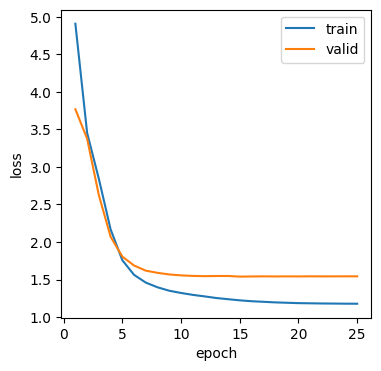

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
epochs = range(1, len(history["train"]) + 1)
ax.plot(epochs, history["train"], label="train")
ax.plot(epochs, history["valid"], label="valid")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
plt.show()

# Qualitative checks

In [14]:
# Load track lookup, keep only columns we need, inner-join with vocab
lookup = pd.read_parquet(
    "../data/playlist/track_lookup.parquet",
    columns=["track_rowid", "track_name", "artist_name", "track_popularity"],
)
lookup = lookup.merge(vocab, on="track_rowid", how="inner")
print(f"{len(lookup):,} tracks in lookup (should match vocab size {len(vocab):,})")
lookup.head()

169,196 tracks in lookup (should match vocab size 169,196)


,track_rowid,track_name,artist_name,track_popularity,playlist_count,track_id
0,1,The Giver,Chappell Roan,89,65,0
1,8,SMOKE THE PAIN AWAY,Calvin Harris,75,24,1
2,12,Relationships,HAIM,72,42,2
3,21,Sunset Blvd,Selena Gomez,78,16,3
4,22,Still Bad,Lizzo,73,10,4


In [15]:
# L2-normalise embeddings once — cosine sim becomes a simple matmul
emb = model.track_embeddings.to(device)
emb_norm = emb / emb.norm(dim=1, keepdim=True)


def find_neighbours(query: str, k: int = 10, diverse: bool = True) -> pd.DataFrame:
    """Find top-k nearest neighbours by cosine similarity.

    `query` is matched case-insensitively against track_name. If multiple tracks
    match, the most popular one is used.
    If `diverse=True`, at most one track per artist is returned.
    """
    matches = lookup[lookup["track_name"].str.contains(query, case=False, na=False)]
    if matches.empty:
        print(f"No tracks matching '{query}'")
        return pd.DataFrame()

    row = matches.sort_values("track_popularity", ascending=False).iloc[0]
    tid = row["track_id"]
    print(f"Query: {row['track_name']} — {row['artist_name']}  (pop {row['track_popularity']})")

    sims = (emb_norm[tid] @ emb_norm.T).cpu().numpy()

    candidates = lookup.copy()
    candidates["similarity"] = sims[candidates["track_id"].values]
    candidates = candidates[candidates["track_id"] != tid]
    candidates = candidates.sort_values("similarity", ascending=False)
    if diverse:
        candidates = candidates.drop_duplicates(subset="artist_name")
    return candidates.head(k)[["track_name", "artist_name", "track_popularity", "similarity"]]

In [16]:
queries = [
    "Holland, 1945",
    "when you sleep",
    "Interzone",
    "About A Girl",
    "Battery",
    "Xtal",
    "Altibzz",
    "N.Y. State of Mind",
    "Mathematics",
    "Nuthin' But A 'G' Thang",
    "Figaro",
    "Bela Lugosi's Dead",
    "Just Like Heaven",
    "Once in a Lifetime",
    "Dunkelheit",
    "Valvonauta",
]

for q in queries:
    display(find_neighbours(q))
    print()

Query: Holland, 1945 — Neutral Milk Hotel  (pop 0)


,track_name,artist_name,track_popularity,similarity
116097,King of Carrot Flowers Pt. 1,Neutral Milk Hotel,0,0.912658
96225,A.M. 180,Grandaddy,47,0.910434
99103,Marquee Moon - 2003 Remaster,Television,37,0.909645
83641,Crooked Teeth,Death Cab for Cutie,54,0.909622
121879,Bull In The Heather,Sonic Youth,52,0.906987
10907,"Yoshimi Battles the Pink Robots, Pt. 1",The Flaming Lips,59,0.904201
101647,Kiss Off - 2002 Remastered Version,Violent Femmes,0,0.903000
116064,Come On Let's Go,Broadcast,0,0.902015
120567,Sometimes Always,The Jesus and Mary Chain,44,0.901812
127776,Is There A Ghost,Band of Horses,0,0.900180



Query: When You Sleep — my bloody valentine  (pop 62)


,track_name,artist_name,track_popularity,similarity
11105,Petals,Hole,64,0.914557
74058,It's Only Sex,Car Seat Headrest,60,0.909499
113258,All I Think About Now,Pixies,0,0.889324
12415,Teenager,Deftones,55,0.889200
113309,Murder Your Memory,Title Fight,38,0.885532
11083,Marigold,Nirvana,64,0.880909
116155,flutter,julie,52,0.879391
117201,All They Wanted,Panchiko,67,0.875816
9908,Bloodhail,Have A Nice Life,59,0.872780
96327,Milk,Sweet Trip,46,0.871528



No tracks matching 'Interzone'


...

,track_name,artist_name,track_popularity,similarity
90824,Rise,Public Image Ltd.,44,0.899727
102306,Senses Working Overtime - Remastered 2001,XTC,50,0.877295
30375,Burning Down the House,Talking Heads,68,0.876109
137288,It's The End Of The World As We Know It (And I...,R.E.M.,48,0.873293
102479,Peaches - 1996 Remaster,The Stranglers,53,0.871276
87343,One Thing Leads To Another,The Fixx,51,0.866090
137395,Tenderness,General Public,0,0.862378
108040,I Melt with You,Modern English,0,0.859233
95213,Reptile,The Church,52,0.858287
101442,Watching The Detectives - Single Version,Elvis Costello,52,0.858037



No tracks matching 'Dunkelheit'


""



No tracks matching 'Valvonauta'


""
